In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
import data_preprocessing.ABC_priors_and_functions as ABC
import data_preprocessing.plotting_functions as ABC_plot
import data_preprocessing.data_preprocessing as data
import data_preprocessing.stochastic_systems_models as SSM
import ete3

SMALL_SIZE = 15
MEDIUM_SIZE = 15
BIGGER_SIZE = 21

plt.rc('font', size=BIGGER_SIZE)          # controls default text sizes
plt.rc('axes', titlesize=BIGGER_SIZE)     # fontsize of the axes title
plt.rc('axes', labelsize=BIGGER_SIZE)    # fontsize of the x and y labels
plt.rc('xtick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('ytick', labelsize=SMALL_SIZE)    # fontsize of the tick labels
plt.rc('legend', fontsize=SMALL_SIZE)    # legend fontsize
plt.rc('figure', titlesize=BIGGER_SIZE)  # fontsize of the figure title

In [2]:
params = np.load("./data_preprocessing/simulated_ABC_data/chase/accepted_extended_three_population_chase_pulse_params.npy")

#Uncomment whichever posterior parameter you wish to simulate

#param = params[8] #fast coalescent rate parameter
param = params[3] #slow coalescent rate parameter

This notebook ....


To construct a coalescent tree from the three population model, we first forward simulate, and save all of the information needed to build a tree from (ie, every event that happens (birth, death, migration, etc), the time at which they happen, and the molecule it happens to)

In [ ]:
#forward simulate and record information of every event
event_times, event_indexes, molecule_indexes, nucleoid_state = SSM.extended_three_population_forward_coalescent(param, N=500)

During the forward simulation, many molecules will die before reaching the end, and thus will not appear in the coalescent tree. Any event that happens to these molecules is thus irrelevant, and we remove this information from the pool before building a tree

In [13]:
rep_coalescent, young_coalescent, old_coalescent, coalescent_times, coalescent_event_indexes, coalescent_molecule_indexes = SSM.extract_coalescent_info(event_times, event_indexes, molecule_indexes, nucleoid_state)

Having extracted all of the relevant information, we backwards propagate and build an ete3 tree object representing the coalescent tree of every molecule at present

In [14]:
tree = SSM.build_tree_object(rep_coalescent, young_coalescent, old_coalescent, coalescent_event_indexes, coalescent_molecule_indexes)

Usually, we only have access to some small number of molecules from which to infer a tree, not the whole pool. We thus take a subtree of this big tree representing the coalescent tree of a select few mtDNA molecules

In [15]:
subtree = SSM.subsample_tree(tree, 0, 4, 0, coalescent_times, seed = 0, random = True)

0
1
3


A rough view of what the simulated subtree looks like:

In [16]:
print(subtree[0])


                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                     /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- /- 

And a full view of the simulated subtree, saved as a pdf file

In [17]:
ts = ete3.TreeStyle()
ts.show_leaf_name = False
ts.branch_vertical_margin = 10 # 10 pixels between adjacent branches
ts.scale =  0.2

subtree[0].render("subtree_example.pdf", tree_style = ts)

{'nodes': [],
 'faces': [],
 'node_areas': {0: [1.0, 1.0, 398.0587187378291, 81.0],
  1: [1.2, 1.0, 398.05871873782905, 61.0],
  2: [1.2359756849138648, 1.0, 398.05871873782905, 61.0],
  3: [12.861019136469986, 1.0, 398.05871873782905, 61.0],
  4: [12.993705303962633, 1.0, 398.0587187378291, 61.0],
  5: [15.962732793907344, 1.0, 398.05871873782905, 61.0],
  6: [16.211697040259605, 1.0, 398.05871873782905, 61.0],
  7: [18.007284867434645, 1.0, 398.05871873782905, 61.0],
  8: [18.11546331386926, 1.0, 398.05871873782905, 61.0],
  9: [19.427285935472174, 1.0, 398.05871873782905, 61.0],
  10: [20.048834083207478, 1.0, 398.058718737829, 61.0],
  11: [29.163403962599116, 1.0, 398.058718737829, 61.0],
  12: [29.48724619039422, 1.0, 398.058718737829, 61.0],
  13: [30.83477145399957, 1.0, 398.058718737829, 61.0],
  14: [31.02412810209644, 1.0, 398.058718737829, 61.0],
  15: [34.34846807990107, 1.0, 398.058718737829, 61.0],
  16: [34.360476666063185, 1.0, 398.058718737829, 61.0],
  17: [34.865419

Next, we simulate the site frequency spectrum (SFS) for the previously chosen parameter, for a select number of years. This histogram is computed over num_iter of cells: the larger this value is, the closer the histogram will be to the 'true' SFS, but the longer the simulation will take. 

0


1
2
3
4
5
6
7
8
9


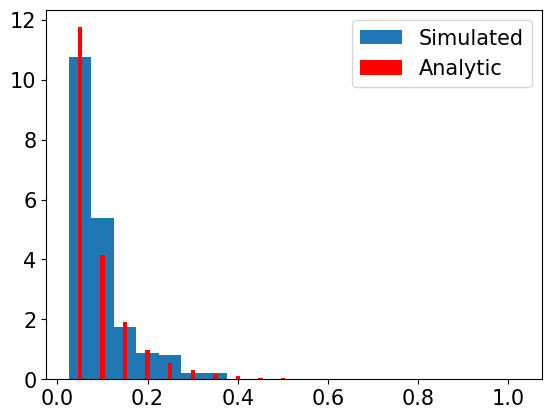

In [12]:
#edit these as you wish. The higher they are, the longer the simulation will take.
num_iter = 10
time = 0.2 #in years

#simulating the SFS
all_statistics = []
for i in range(num_iter):
    print(i)
    np.random.seed(i)
    cSFS, _, _, _ = SSM.extended_three_population_mutational_forward_coalescent(param, truncation_time = time, mutation_probability = 0.05, N=900)
    all_statistics.append(cSFS)

simulated_SFS = np.concatenate(all_statistics)

#analytically computing the SFS
analytic_SFS = SSM.expected_SFS(param, n=20, truncation_time = time)

#plotting
_ = plt.hist(simulated_SFS, bins = np.arange(0,21)/20 + 0.025, density=True, label = "Simulated")
plt.bar(np.arange(1,21)/20, analytic_SFS*20, 0.01, color = "r", label = "Analytic")
plt.legend()


Here we plot some pre-simulated SFSs (with a more realistic mutation probability of 0.00066, and n_iter=2000)

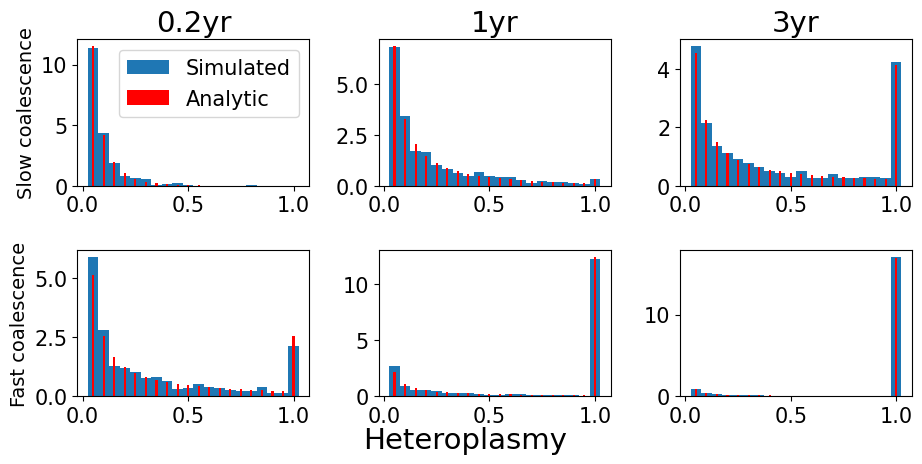

In [ ]:
#loading pre-simulated SFSs
ep3_SFS_1y = np.load("./data_preprocessing/simulated_SFSs/ep3_N900_n20_SFS_1y.npy")
ep3_SFS_0_2y = np.load("./data_preprocessing/simulated_SFSs/ep3_N900_n20_SFS_0.2y.npy")
ep3_SFS_3y = np.load("./data_preprocessing/simulated_SFSs/ep3_N900_n20_SFS_3y.npy")

ep12_SFS_1y = np.load("./data_preprocessing/simulated_SFSs/ep8_N900_n20_SFS_1y.npy")
ep12_SFS_0_2y = np.load("./data_preprocessing/simulated_SFSs/ep8_N900_n20_SFS_0.2y.npy")
ep12_SFS_3y = np.load("./data_preprocessing/simulated_SFSs/ep8_N900_n20_SFS_3y.npy")

#calculating their analytic SFS
ESFS_0_2 = SSM.expected_SFS(params[3], 0.2, n=20, N = 900)
ESFS_1 = SSM.expected_SFS(params[3], 1, n=20, N = 900)
ESFS_3 = SSM.expected_SFS(params[3], 3, n=20, N = 900)

ESFS1_0_2 = SSM.expected_SFS(params[8], 0.2, n=20, N = 900)
ESFS1_1 = SSM.expected_SFS(params[8], 1, n=20, N = 900)
ESFS1_3 = SSM.expected_SFS(params[8], 3, n=20, N = 900)

#plotting
fig, ax = plt.subplots(2,3, figsize = (8*1.2,4*1.2))

_ = ax[0,0].hist(ep3_SFS_0_2y, bins = np.arange(0,21)/20 + 0.025, density=True, label = "Simulated")
ax[0,0].bar(np.arange(1,21)/20, ESFS_0_2*20, 0.01, color = "r", label = "Analytic")
_ = ax[0,1].hist(ep3_SFS_1y, bins = np.arange(0,21)/20 + 0.025, density=True)
ax[0,1].bar(np.arange(1,21)/20, ESFS_1*20, 0.01, color = "r")
_ = ax[0,2].hist(ep3_SFS_3y, bins = np.arange(0,21)/20 + 0.025, density=True)
ax[0,2].bar(np.arange(1,21)/20, ESFS_3*20, 0.01, color = "r")

_ = ax[1,0].hist(ep12_SFS_0_2y, bins = np.arange(0,21)/20 + 0.025, density=True, label = "Simulated")
ax[1,0].bar(np.arange(1,21)/20, ESFS1_0_2*20, 0.01, color = "r", label = "Analytic")
_ = ax[1,1].hist(ep12_SFS_1y, bins = np.arange(0,21)/20 + 0.025, density=True)
ax[1,1].bar(np.arange(1,21)/20, ESFS1_1*20, 0.01, color = "r")
_ = ax[1,2].hist(ep12_SFS_3y, bins = np.arange(0,21)/20 + 0.025, density=True)
ax[1,2].bar(np.arange(1,21)/20, ESFS1_3*20, 0.01, color = "r")

ax[0,0].legend()

fig.text(0.5, 0.02, 'Heteroplasmy', ha='center')
#fig.text(0.05, 0.5, 'Density', va='center', rotation='vertical')

ax[0,0].set_ylabel("Slow coalescence", fontsize = 14)
ax[1,0].set_ylabel("Fast coalescence", fontsize =14)

ax[0,0].set_title("0.2yr")
ax[0,1].set_title("1yr")
ax[0,2].set_title("3yr")

plt.tight_layout()
